# Phase II Text and Issue Analysis

This notebook extends the descriptive Phase II analysis into review-content analysis.

The objective is to identify the product issues discussed in negative reviews and compare whether the same application receives different types of complaints across Google Play Store and Apple App Store.

The initial analysis focuses on three paired applications:

- Venmo
- Pandora
- Lyft

These applications were selected because they show meaningful cross-platform rating differences while having relatively more comparable timestamp coverage than many of the largest-gap applications.

The analysis will proceed from manual review inspection to structured issue classification rather than applying advanced NLP immediately.

In [28]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

APPLE_PATH = ROOT / "data" / "processed" / "apple_store_analysis.csv"
GOOGLE_PATH = ROOT / "data" / "processed" / "google_play_analysis.csv"

apple = pd.read_csv(APPLE_PATH)
google = pd.read_csv(GOOGLE_PATH)

print("Apple shape:", apple.shape)
print("Google shape:", google.shape)

Apple shape: (13599, 14)
Google shape: (13599, 15)


In [29]:
apple["analysis_text"] = (
    apple["review_title"].fillna("").astype(str)
    + " "
    + apple["review_text"].fillna("").astype(str)
).str.strip()

google["analysis_text"] = (
    google["review_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

apple["review_length"] = apple["analysis_text"].str.len()
google["review_length"] = google["analysis_text"].str.len()

In [30]:
selected_apps = ["Venmo", "Pandora", "Lyft"]

apple_negative = apple[
    (apple["app_name"].isin(selected_apps))
    & (apple["rating"] <= 2)
].copy()

google_negative = google[
    (google["app_name"].isin(selected_apps))
    & (google["rating"] <= 2)
].copy()

print("Apple negative reviews:", len(apple_negative))
print("Google negative reviews:", len(google_negative))

Apple negative reviews: 577
Google negative reviews: 654


In [31]:
def show_long_negative_reviews(df, app_name, n=10):
    sample = (
        df[df["app_name"] == app_name]
        .sort_values("review_length", ascending=False)
        .head(n)
    )

    return sample[
        ["rating", "review_date", "analysis_text", "review_length"]
    ]


for app in selected_apps:
    print(f"\nAPPLE - {app}")
    display(show_long_negative_reviews(apple_negative, app))

    print(f"\nGOOGLE - {app}")
    display(show_long_negative_reviews(google_negative, app))


APPLE - Venmo


,rating,review_date,analysis_text,review_length
12497,1,2026-08-04 15:48:26+00:00,! 1 STAR ! WILL NOT SHOW MY REVIEW TERRIBLE CU...,1629
12552,1,2026-08-02 23:05:48+00:00,Horrible. What changed?! I’ve been using Venmo...,1609
12402,1,2026-08-06 06:43:11+00:00,ABSOLUTELY RIDICULOUS If I could give 0 stars ...,1475
12443,1,2026-08-05 15:16:05+00:00,"Scam/Fraud I was scammed, but able to stop the...",1401
12335,1,2026-08-07 18:46:03+00:00,"Stuck money, no real customer support I have b...",1363
12582,1,2026-08-02 01:41:05+00:00,How can we trust you when YOU don’t trust your...,1310
12158,1,2026-08-12 14:17:43+00:00,Your payment can’t be completed right now This...,1111
12228,1,2026-08-10 18:32:48+00:00,Misleading AI I was trying to login to close m...,927
12149,1,2026-08-12 17:27:31+00:00,"E-check bull I went to pay rent using Venmo, i...",864
12346,1,2026-08-07 15:05:00+00:00,Works great when it works but untrustworthy Tr...,826



GOOGLE - Venmo


,rating,review_date,analysis_text,review_length
12368,1,2026-08-10 19:11:21+00:00,This platform is BROKEN! Super broken! Account...,500
12117,1,2026-08-13 19:39:34+00:00,DO NOT DOWNLOAD AND WASTE YOUR TIME WITH THIS ...,499
12234,1,2026-08-12 14:50:41+00:00,It's ridiculous how slow it is. It auto refres...,498
12410,1,2026-08-10 03:03:13+00:00,"Necessary evil, but don't use it to receive pa...",497
12261,1,2026-08-12 00:18:37+00:00,Worst app & digital currency company I have ev...,497
12508,1,2026-08-08 18:32:15+00:00,Seems like a simple concept.. send money to fr...,497
12126,1,2026-08-13 18:05:46+00:00,edited to move down from 4 stars to one star. ...,496
12321,1,2026-08-11 10:06:50+00:00,DO NOT GET THIS APP! biggest mistake of my lif...,496
12147,1,2026-08-13 14:04:33+00:00,"The ""help"" section is a joke. The phone number...",495
12462,1,2026-08-09 14:09:47+00:00,the worst for business use dont waste your tim...,495



APPLE - Pandora


...

,rating,review_date,analysis_text,review_length
6484,1,2026-08-11 09:35:24+00:00,I wrote to you several months or years ago reg...,499
6518,2,2026-08-09 00:49:51+00:00,Constantly crashes. I will play a radio statio...,498
6887,1,2026-07-16 18:08:06+00:00,Pandora doesn't get genres very well. You put ...,498
6630,1,2026-07-31 18:36:07+00:00,For years they have had the same issue over an...,497
6786,2,2026-07-22 02:54:35+00:00,I'm so SiKC of Pandora! You people have UPDATE...,497
6944,1,2026-07-13 17:23:45+00:00,I'll be listening to music but after a while i...,497
6806,1,2026-07-21 15:01:08+00:00,"I don't normally leave reviews, but I'm going ...",496
6639,2,2026-07-31 02:10:31+00:00,"Much like another reviewer, only recently have...",496
6722,2,2026-07-25 23:19:57+00:00,"I pay for this app, and no matter what type of...",492
6699,1,2026-07-27 13:22:04+00:00,"I have used this app for more than 10 years, w...",490



APPLE - Lyft


,rating,review_date,analysis_text,review_length
5152,1,2026-08-10 22:55:25+00:00,Extremely frustrating billing bug + terrible c...,1818
5469,2,2026-08-05 08:29:52+00:00,"Great for personal trips, no so great for medi...",1259
5161,1,2026-08-10 21:08:21+00:00,Your scammers This is completely unacceptable ...,1095
5455,1,2026-08-05 16:25:24+00:00,Beware of Billing Issues Absolutely appalling ...,737
5243,1,2026-08-09 04:54:31+00:00,Just take a Taxi Lyft used to be super conveni...,659
5264,1,2026-08-08 20:55:56+00:00,Scammers Uber from now on only. My driver drop...,454
5378,1,2026-08-07 01:10:49+00:00,Scheduled ride credit hard to receive I had a ...,453
5290,1,2026-08-08 11:27:42+00:00,Stranded I had a ride scheduled to pick me up ...,453
5248,1,2026-08-09 02:02:15+00:00,Ugh I’m not very happy. I have never had to wa...,437
5135,1,2026-08-11 12:09:19+00:00,Suck Lyft have to be the WORSE COMPANY to use ...,436



GOOGLE - Lyft


,rating,review_date,analysis_text,review_length
5346,1,2026-08-01 22:04:22+00:00,I've had several drivers admit to being illega...,499
5031,1,2026-08-12 18:36:15+00:00,These drivers are not monitor. there drivers a...,498
5408,1,2026-07-31 09:37:28+00:00,Their ai support is horrible!! it asks you 1 q...,498
5159,1,2026-08-07 17:10:42+00:00,Lyft is terrible! I have constantly been overc...,498
5429,1,2026-07-30 19:06:56+00:00,"The driver did not show up, and my money was n...",497
5402,1,2026-07-31 13:55:24+00:00,recently it's been making sure I'm at least 5 ...,497
5130,1,2026-08-08 21:14:10+00:00,What is the reason that prompts Lyft to remove...,495
5191,1,2026-08-06 20:14:04+00:00,App no longer works. It displays a full screen...,494
5431,1,2026-07-30 18:37:54+00:00,Terrible user experience. I ordered a short 9 ...,493
5281,2,2026-08-03 23:15:57+00:00,I downloaded this app and scheduled a ride. Af...,492


## 6. Initial Issue Taxonomy

A manual inspection of detailed negative reviews suggests several recurring issue types across the selected applications.

Rather than creating a completely different taxonomy for each application, the analysis uses a shared set of broad issue categories to support cross-platform and cross-app comparison.

The initial taxonomy is:

| Issue Category | Description |
|---|---|
| Core Service Failure | The application's main function does not work as expected, such as failed payments, playback failures, or unsuccessful rides |
| Billing / Payment | Charges, fees, refunds, subscriptions, payment processing, or money-related complaints |
| Account / Access | Login, verification, account restrictions, access, or account-management problems |
| Customer Support | Difficulty reaching support, poor support quality, automated support, or unresolved complaints |
| Technical / App Performance | Crashes, bugs, slow performance, buffering, loading, or general technical problems |
| Trust / Safety / Fraud | Fraud, scams, security concerns, unsafe experiences, or trust-related complaints |
| Product Experience / Features | Search, recommendation, interface, missing features, usability, or changes to product functionality |
| Ads / Subscription | Advertising frequency, paid plans, subscription value, or premium-service complaints |
| Service Provider / Fulfillment | Problems involving drivers, ride fulfillment, merchants, or other service-side participants |
| Other | Complaints that do not fit the main categories |

The taxonomy is exploratory and will be validated against a broader sample of reviews before being treated as a stable classification framework.

A review may contain multiple issues, so the classification should allow **multiple labels per review** rather than forcing each review into only one category.

## 7. Text-Length Ceiling Observation

Inspection of the longest reviews reveals an important platform-specific characteristic.

Apple reviews in the selected applications can exceed 1,000 characters, with some reviews reaching more than 1,600 characters.

In contrast, the longest collected Google Play review texts consistently approach but do not exceed approximately 500 characters.

This suggests that the observed cross-platform review-length difference may partly reflect a platform or collection-level text-length constraint rather than only differences in user writing behavior.

Therefore, the finding that Apple reviews contain more text should be interpreted as an observed dataset characteristic rather than evidence that Apple users inherently provide more detailed feedback.

In [32]:
issue_keywords = {
    "Billing / Payment": [
        "charge", "charged", "billing", "bill", "fee", "fees",
        "refund", "money", "payment", "paid", "subscription",
        "credit", "price", "cost"
    ],

    "Account / Access": [
        "account", "login", "log in", "sign in", "verify",
        "verification", "locked", "access", "password"
    ],

    "Customer Support": [
        "support", "customer service", "help center",
        "representative", "agent", "contact", "phone number"
    ],

    "Technical / App Performance": [
        "crash", "crashes", "bug", "broken", "slow",
        "buffer", "buffering", "load", "loading",
        "freeze", "frozen", "update", "doesn't work",
        "not working"
    ],

    "Trust / Safety / Fraud": [
        "fraud", "scam", "scammer", "security", "unsafe",
        "trust", "stolen", "steal"
    ],

    "Product Experience / Features": [
        "search", "feature", "interface", "recommendation",
        "recommend", "design", "navigation", "genre",
        "station"
    ],

    "Ads / Subscription": [
        "ad", "ads", "advertisement", "premium",
        "subscription", "subscriber"
    ],

    "Service Provider / Fulfillment": [
        "driver", "ride", "pickup", "pick up",
        "no show", "scheduled", "trip"
    ]
}

In [33]:
def classify_issues(text):
    text = str(text).lower()

    labels = []

    for issue, keywords in issue_keywords.items():
        if any(keyword in text for keyword in keywords):
            labels.append(issue)

    if not labels:
        labels.append("Other")

    return labels

In [34]:
apple_negative["issue_labels"] = (
    apple_negative["analysis_text"]
    .apply(classify_issues)
)

google_negative["issue_labels"] = (
    google_negative["analysis_text"]
    .apply(classify_issues)
)

display(
    apple_negative[
        ["app_name", "rating", "analysis_text", "issue_labels"]
    ].head(10)
)

,app_name,rating,analysis_text,issue_labels
5001,Lyft,1,Account disabled ?? For no good reason my acco...,"[Account / Access, Service Provider / Fulfillm..."
5008,Lyft,1,"Price Honestly, I know it’s inflation but you ...","[Billing / Payment, Ads / Subscription]"
5009,Lyft,1,Not for people without domestic cell service H...,[Product Experience / Features]
5011,Lyft,2,Expenses Lyft is just to expensive on average,[Other]
5013,Lyft,2,Scammy pricing Only on this app can you pay $2...,"[Trust / Safety / Fraud, Service Provider / Fu..."
5015,Lyft,1,drivers drivers do not get held accountable fo...,"[Billing / Payment, Account / Access, Service ..."
5021,Lyft,1,Late schedule ride I scheduled a ride for my f...,"[Ads / Subscription, Service Provider / Fulfil..."
5040,Lyft,1,expensiveee paid for lyft pink and still expen...,[Billing / Payment]
5044,Lyft,1,Absurdly Stupid Prices! Looked up a location t...,"[Billing / Payment, Service Provider / Fulfill..."
5050,Lyft,2,Gone downhill I used to always use Lyft over u...,"[Billing / Payment, Technical / App Performance]"


In [35]:
import re
def contains_keyword(text, keyword):
    text = str(text).lower()

    # Multi-word phrases
    if " " in keyword or "'" in keyword:
        return keyword.lower() in text

    # Single words: match whole words only
    pattern = rf"\b{re.escape(keyword.lower())}\b"

    return re.search(pattern, text) is not None


def classify_issues(text):
    labels = []

    for issue, keywords in issue_keywords.items():
        if any(contains_keyword(text, keyword) for keyword in keywords):
            labels.append(issue)

    if not labels:
        labels.append("Other")

    return labels

apple_negative["issue_labels"] = (
    apple_negative["analysis_text"]
    .apply(classify_issues)
)

google_negative["issue_labels"] = (
    google_negative["analysis_text"]
    .apply(classify_issues)
)

In [36]:
apple_validation = (
    apple_negative[
        ["app_name", "rating", "analysis_text", "issue_labels"]
    ]
    .sample(n=15, random_state=42)
)

google_validation = (
    google_negative[
        ["app_name", "rating", "analysis_text", "issue_labels"]
    ]
    .sample(n=15, random_state=42)
)

print("APPLE VALIDATION SAMPLE")
display(apple_validation)

print("GOOGLE VALIDATION SAMPLE")
display(google_validation)

APPLE VALIDATION SAMPLE


,app_name,rating,analysis_text,issue_labels
6598,Pandora,2,Struggle is real My life took a turn for the b...,[Other]
12374,Venmo,1,Won’t let me close business account. $0 balanc...,[Account / Access]
12524,Venmo,1,Not worth it. Does anyone actually work here? ...,[Other]
5499,Lyft,2,Luft There is no way on that app to delete you...,"[Billing / Payment, Service Provider / Fulfill..."
12434,Venmo,1,Venmo will no longer connect with my bank I us...,"[Billing / Payment, Customer Support]"
6890,Pandora,2,Make it free! I hate not being able to skip th...,[Other]
12131,Venmo,1,Holding funds Venmo is holding my money for ov...,"[Billing / Payment, Customer Support]"
5157,Lyft,1,Time wasters They had me waiting for over 12 m...,[Other]
5437,Lyft,1,Expense Way more expensive than uber but able ...,[Service Provider / Fulfillment]
12150,Venmo,1,Does not work Doesn't work,[Technical / App Performance]


GOOGLE VALIDATION SAMPLE


,app_name,rating,analysis_text,issue_labels
6748,Pandora,1,App won't respond and hasn't worked in over a ...,[Other]
5180,Lyft,1,"There is no problem with my driver's license, ...","[Account / Access, Service Provider / Fulfillm..."
12293,Venmo,1,well tried to send money to someone and they w...,"[Billing / Payment, Account / Access, Customer..."
6639,Pandora,2,"Much like another reviewer, only recently have...",[Technical / App Performance]
6813,Pandora,1,Pandora is worst then Sirius radio and Spotify...,[Other]
12587,Venmo,1,Support people are argumentative idiots that c...,[Customer Support]
5129,Lyft,1,cannot get a car because no human works for th...,[Customer Support]
5158,Lyft,2,"Lyft is sufficient. The app, however, lies. Wh...",[Service Provider / Fulfillment]
5369,Lyft,1,"worst app, drivers cancel last minute, doesn't...","[Product Experience / Features, Service Provid..."
5125,Lyft,1,Just such a deceptive business on every level....,[Billing / Payment]


## 8. Taxonomy Validation and Refinement

Manual validation of randomly sampled negative reviews shows that the initial keyword-based classifier captures many obvious issues, but several systematic gaps remain.

The main problems are:

- Some clear technical complaints are currently classified as `Other`, especially phrases such as "won't respond" or "stops after reboot".
- Product-specific complaints such as Pandora skipping limitations are not fully captured by the shared taxonomy.
- Lyft fulfillment complaints such as long waits, late drivers, and cancelled rides require more specific keywords.
- Applying the same service-related keywords to every application can create semantically inappropriate labels.

The classifier is therefore refined using a combination of:

1. **Shared issue keywords** for problems that have similar meaning across applications.
2. **App-specific keywords** for core-service and product-specific issues.

The classification remains multi-label because a single review may describe multiple problems.

In [37]:
import re

shared_issue_keywords = {
    "Billing / Payment": [
        "charge", "charged", "billing", "bill", "fee", "fees",
        "refund", "money", "payment", "paid",
        "price", "pricing", "expensive", "cost", "fare"
    ],

    "Account / Access": [
        "account", "login", "log in", "sign in",
        "verify", "verification", "locked",
        "access", "password"
    ],

    "Customer Support": [
        "support", "customer service", "help center",
        "representative", "agent", "contact",
        "phone number"
    ],

    "Technical / App Performance": [
        "crash", "crashes", "bug", "bugs",
        "broken", "slow", "buffer", "buffering",
        "load", "loading", "freeze", "frozen",
        "doesn't work", "does not work", "not working",
        "won't work", "won't respond", "hasn't worked"
    ],

    "Trust / Safety / Fraud": [
        "fraud", "scam", "scammer",
        "security", "unsafe", "stolen",
        "steal", "deceptive"
    ],

    "Product Experience / Features": [
        "search", "feature", "features",
        "interface", "recommendation", "recommend",
        "design", "navigation"
    ],

    "Ads / Subscription": [
        "ad", "ads", "advertisement",
        "premium", "subscription", "subscriber"
    ]
}


app_specific_keywords = {
    "Venmo": {
        "Core Service Failure": [
            "send money", "receive money",
            "transfer", "transaction",
            "direct deposit", "payment failed",
            "connect with my bank"
        ]
    },

    "Pandora": {
        "Core Service Failure": [
            "won't play", "doesn't play",
            "not playing", "playback",
            "music stops", "song stops"
        ],

        "Technical / App Performance": [
            "stops", "reboot"
        ],

        "Product Experience / Features": [
            "skip", "can't skip", "cannot skip",
            "station", "stations"
        ],

        "Ads / Subscription": [
            "free"
        ]
    },

    "Lyft": {
        "Core Service Failure": [
            "can't get a ride", "cannot get a ride",
            "get a car", "no driver",
            "scheduled ride", "ride canceled",
            "ride cancelled"
        ],

        "Service Provider / Fulfillment": [
            "driver", "drivers",
            "ride", "rides",
            "pickup", "pick up",
            "no show", "scheduled",
            "waiting", "waited",
            "on time", "late",
            "canceled", "cancelled"
        ]
    }
}


def contains_keyword(text, keyword):
    text = str(text).lower()
    keyword = keyword.lower()

    # Phrase matching
    if " " in keyword or "'" in keyword:
        return keyword in text

    # Whole-word matching
    pattern = rf"\b{re.escape(keyword)}\b"
    return re.search(pattern, text) is not None


def classify_issues(text, app_name):
    labels = []

    # Shared taxonomy
    for issue, keywords in shared_issue_keywords.items():
        if any(contains_keyword(text, keyword) for keyword in keywords):
            labels.append(issue)

    # App-specific taxonomy
    app_rules = app_specific_keywords.get(app_name, {})

    for issue, keywords in app_rules.items():
        if any(contains_keyword(text, keyword) for keyword in keywords):
            labels.append(issue)

    # Remove repeated labels while preserving order
    labels = list(dict.fromkeys(labels))

    if not labels:
        labels = ["Other"]

    return labels

In [38]:
apple_negative["issue_labels"] = apple_negative.apply(
    lambda row: classify_issues(
        row["analysis_text"],
        row["app_name"]
    ),
    axis=1
)

google_negative["issue_labels"] = google_negative.apply(
    lambda row: classify_issues(
        row["analysis_text"],
        row["app_name"]
    ),
    axis=1
)

In [39]:
def classification_coverage(df, platform):
    temp = df.copy()

    temp["is_other"] = temp["issue_labels"].apply(
        lambda labels: labels == ["Other"]
    )

    temp["label_count"] = temp["issue_labels"].apply(
        lambda labels: len(labels)
    )

    summary = (
        temp.groupby("app_name")
        .agg(
            negative_reviews=("review_id", "count"),
            other_reviews=("is_other", "sum"),
            average_labels=("label_count", "mean")
        )
    )

    summary["Other Rate (%)"] = (
        summary["other_reviews"]
        / summary["negative_reviews"]
        * 100
    )

    summary["platform"] = platform

    return summary.reset_index()


coverage_summary = pd.concat(
    [
        classification_coverage(
            apple_negative,
            "Apple App Store"
        ),
        classification_coverage(
            google_negative,
            "Google Play"
        )
    ],
    ignore_index=True
)

display(
    coverage_summary[
        [
            "platform",
            "app_name",
            "negative_reviews",
            "other_reviews",
            "Other Rate (%)",
            "average_labels"
        ]
    ].round(2)
)

,platform,app_name,negative_reviews,other_reviews,Other Rate (%),average_labels
0,Apple App Store,Lyft,102,18,17.65,1.46
1,Apple App Store,Pandora,64,21,32.81,1.34
2,Apple App Store,Venmo,411,78,18.98,1.78
3,Google Play,Lyft,212,33,15.57,1.68
4,Google Play,Pandora,193,83,43.01,1.18
5,Google Play,Venmo,249,56,22.49,1.68


In [40]:
## Inspect Pandora reviews still classified as Other

def get_other_reviews(df, app_name, n=15):
    subset = df[
        (df["app_name"] == app_name)
        & (df["issue_labels"].apply(lambda x: x == ["Other"]))
    ].copy()

    print(f"Total Other reviews for {app_name}: {len(subset)}")

    if len(subset) == 0:
        return subset

    return (
        subset[
            [
                "rating",
                "review_date",
                "analysis_text",
                "review_length",
                "issue_labels"
            ]
        ]
        .sample(
            n=min(n, len(subset)),
            random_state=42
        )
    )


print("APPLE PANDORA - OTHER REVIEWS")
display(
    get_other_reviews(
        apple_negative,
        "Pandora",
        n=15
    )
)

print("GOOGLE PANDORA - OTHER REVIEWS")
display(
    get_other_reviews(
        google_negative,
        "Pandora",
        n=15
    )
)

APPLE PANDORA - OTHER REVIEWS
Total Other reviews for Pandora: 21


,rating,review_date,analysis_text,review_length,issue_labels
6537,2,2026-08-09 16:49:15+00:00,Mid Too many adds between songs takes forever ...,112,[Other]
6888,1,2026-07-26 00:42:23+00:00,Pandora politics vrs music which brings people...,193,[Other]
6850,1,2026-07-27 13:32:13+00:00,What am I paying for? I can’t pick songs anymo...,56,[Other]
6553,1,2026-08-09 02:54:34+00:00,No Longer Works on Apple Watch 3 App was great...,215,[Other]
6745,1,2026-07-31 11:13:03+00:00,Redundant I get the same tunes every artist it...,53,[Other]
6598,2,2026-08-07 02:23:51+00:00,Struggle is real My life took a turn for the b...,237,[Other]
6786,2,2026-07-30 05:12:02+00:00,Wow really? Limited playing? I don’t want a te...,69,[Other]
6593,1,2026-08-07 15:01:53+00:00,Sucks Have to watch a add every five seconds d...,72,[Other]
6895,2,2026-07-25 15:07:33+00:00,Istg. I wish y’all would give us the ability t...,310,[Other]
6886,1,2026-07-26 02:01:10+00:00,This app is trash What you mean I have to wait...,148,[Other]


GOOGLE PANDORA - OTHER REVIEWS
Total Other reviews for Pandora: 83


,rating,review_date,analysis_text,review_length,issue_labels
6627,1,2026-07-31 21:15:27+00:00,I installed it but it doesn't allow me to play it,49,[Other]
6462,1,2026-08-13 00:34:29+00:00,no matter what I do I can't change anything on...,176,[Other]
6610,1,2026-08-02 03:05:01+00:00,I cannot connect my Bluetooth speaker why,41,[Other]
6629,1,2026-07-31 18:48:35+00:00,it sucks,8,[Other]
6580,1,2026-08-04 16:21:07+00:00,"Neverending ""technical difficulties"" when tryi...",96,[Other]
6621,1,2026-08-01 03:58:49+00:00,"terrible, counterintuitive, always glitching, ...",80,[Other]
6506,1,2026-08-09 21:45:15+00:00,problem with the app over heating my phone... ...,146,[Other]
6753,1,2026-07-24 10:03:07+00:00,"worst music app ever, constantly crashing and ...",60,[Other]
6476,1,2026-08-12 00:36:17+00:00,why is it that people can hide sexually explic...,85,[Other]
6526,1,2026-08-07 19:45:17+00:00,I love the app but keeps stopping,33,[Other]


## 9. Pandora Taxonomy Refinement

Inspection of reviews still classified as `Other` reveals several recurring Pandora-specific patterns that were not captured by the initial rules.

The main gaps are:

- Advertising complaints expressed using variants such as "advertisements" or misspelled forms of "ads"
- Limited song selection, inability to choose songs, and repetitive music
- Playback failures and repeated stopping or closing
- Device and compatibility problems involving Bluetooth or Apple Watch
- Technical complaints using terms such as "glitching", "technical difficulties", and overheating

A small number of reviews discuss unrelated or highly specific concerns, such as political content or individual content-moderation complaints. These are retained as `Other` rather than expanding the taxonomy around isolated examples.

The goal of refinement is to capture recurring and business-relevant issue patterns, not to eliminate the `Other` category completely.

In [41]:
shared_issue_keywords = {
    "Billing / Payment": [
        "charge", "charged", "billing", "bill",
        "fee", "fees", "refund", "money",
        "payment", "paid", "paying",
        "price", "pricing", "expensive",
        "cost", "fare", "purchase"
    ],

    "Account / Access": [
        "account", "login", "log in", "sign in",
        "verify", "verification", "locked",
        "access", "password"
    ],

    "Customer Support": [
        "support", "customer service", "help center",
        "representative", "agent", "contact",
        "phone number"
    ],

    "Technical / App Performance": [
        "crash", "crashes", "crashing",
        "bug", "bugs", "broken",
        "slow", "buffer", "buffering",
        "load", "loading",
        "freeze", "frozen",
        "glitch", "glitches", "glitching",
        "technical difficulties",
        "overheat", "overheating",
        "closes", "closing",
        "stops", "stopping", "stopped",
        "doesn't work", "does not work",
        "doesnt work", "not working",
        "won't work", "wont work",
        "won't respond", "hasn't worked",
        "update"
    ],

    "Trust / Safety / Fraud": [
        "fraud", "scam", "scammer",
        "security", "unsafe",
        "stolen", "steal", "deceptive"
    ],

    "Product Experience / Features": [
        "search", "feature", "features",
        "interface", "recommendation",
        "recommend", "design", "navigation"
    ],

    "Ads / Subscription": [
        "ad", "ads", "advertisement",
        "advertisements",
        "commercial", "commercials",
        "premium", "subscription", "subscriber"
    ]
}

In [42]:
shared_issue_keywords_v2 = {
    "Billing / Payment": [
        "charge", "charged", "billing", "bill",
        "fee", "fees", "refund", "money",
        "payment", "paid", "paying",
        "price", "pricing", "expensive",
        "cost", "fare", "purchase"
    ],

    "Account / Access": [
        "account", "login", "log in", "sign in",
        "verify", "verification", "locked",
        "access", "password"
    ],

    "Customer Support": [
        "support", "customer service", "help center",
        "representative", "agent", "contact",
        "phone number"
    ],

    "Technical / App Performance": [
        "crash", "crashes", "crashing",
        "bug", "bugs", "broken",
        "slow", "buffer", "buffering",
        "load", "loading",
        "freeze", "frozen",
        "glitch", "glitches", "glitching",
        "technical difficulties",
        "overheat", "overheating",
        "closes", "closing",
        "stops", "stopping", "stopped",
        "doesn't work", "does not work",
        "doesnt work", "not working",
        "won't work", "wont work",
        "won't respond", "hasn't worked",
        "update"
    ],

    "Trust / Safety / Fraud": [
        "fraud", "scam", "scammer",
        "security", "unsafe",
        "stolen", "steal", "deceptive"
    ],

    "Product Experience / Features": [
        "search", "feature", "features",
        "interface", "recommendation",
        "recommend", "design", "navigation"
    ],

    "Ads / Subscription": [
        "ad", "ads", "advertisement",
        "advertisements",
        "commercial", "commercials",
        "premium", "subscription", "subscriber"
    ]
}


app_specific_keywords_v2 = {
    "Venmo": app_specific_keywords["Venmo"],

    "Pandora": {
        "Core Service Failure": [
            "won't play", "wont play",
            "doesn't play", "does not play",
            "not playing",
            "can't play", "cannot play",
            "can't get it to play",
            "doesn't allow me to play",
            "playback"
        ],

        "Technical / App Performance": [
            "apple watch",
            "bluetooth",
            "speaker",
            "reboot",
            "keeps stopping",
            "keeps closing"
        ],

        "Product Experience / Features": [
            "skip", "can't skip", "cannot skip",
            "pick songs", "choose songs",
            "same songs", "same tunes",
            "same music",
            "over and over",
            "limited playing",
            "station", "stations",
            "playlist", "playlists",
            "on demand"
        ],

        "Ads / Subscription": [
            "too many adds",
            "watch a add",
            "free version"
        ]
    },

    "Lyft": app_specific_keywords["Lyft"]
}

In [43]:
def classify_issues_v2(text, app_name):
    labels = []

    for issue, keywords in shared_issue_keywords_v2.items():
        if any(contains_keyword(text, keyword) for keyword in keywords):
            labels.append(issue)

    app_rules = app_specific_keywords_v2.get(app_name, {})

    for issue, keywords in app_rules.items():
        if any(contains_keyword(text, keyword) for keyword in keywords):
            labels.append(issue)

    labels = list(dict.fromkeys(labels))

    if not labels:
        labels = ["Other"]

    return labels

In [44]:
apple_negative["issue_labels_v2"] = apple_negative.apply(
    lambda row: classify_issues_v2(
        row["analysis_text"],
        row["app_name"]
    ),
    axis=1
)

google_negative["issue_labels_v2"] = google_negative.apply(
    lambda row: classify_issues_v2(
        row["analysis_text"],
        row["app_name"]
    ),
    axis=1
)

### Taxonomy Versioning

The initial taxonomy is preserved as Version 1.

Following manual validation of reviews classified as `Other`, a refined Version 2 is created rather than overwriting the original rules.

This preserves the development history and allows the effect of taxonomy refinement to be evaluated directly.

## 10. Version 1 vs Version 2 Coverage Comparison

The refined taxonomy is evaluated against Version 1 before using it for issue-frequency analysis.

The purpose is to determine whether the Version 2 rules reduce the share of negative reviews classified only as `Other`, particularly for Pandora, while preserving the original taxonomy for comparison.

A lower `Other` rate indicates broader taxonomy coverage, but does not by itself prove higher classification accuracy. Manual validation remains necessary.

In [45]:
def compare_taxonomy_versions(df, platform):
    rows = []

    for app_name in sorted(df["app_name"].unique()):

        app_df = df[df["app_name"] == app_name]

        total = len(app_df)

        v1_other = (
            app_df["issue_labels"]
            .apply(lambda x: x == ["Other"])
            .sum()
        )

        v2_other = (
            app_df["issue_labels_v2"]
            .apply(lambda x: x == ["Other"])
            .sum()
        )

        rows.append({
            "platform": platform,
            "app_name": app_name,
            "negative_reviews": total,
            "V1 Other Reviews": v1_other,
            "V1 Other Rate (%)": v1_other / total * 100,
            "V2 Other Reviews": v2_other,
            "V2 Other Rate (%)": v2_other / total * 100,
            "Other Rate Change (pp)": (
                v2_other / total * 100
                - v1_other / total * 100
            )
        })

    return pd.DataFrame(rows)


version_comparison = pd.concat(
    [
        compare_taxonomy_versions(
            apple_negative,
            "Apple App Store"
        ),
        compare_taxonomy_versions(
            google_negative,
            "Google Play"
        )
    ],
    ignore_index=True
)

display(version_comparison.round(2))

,platform,app_name,negative_reviews,V1 Other Reviews,V1 Other Rate (%),V2 Other Reviews,V2 Other Rate (%),Other Rate Change (pp)
0,Apple App Store,Lyft,102,18,17.65,18,17.65,0.00
1,Apple App Store,Pandora,64,21,32.81,8,12.50,-20.31
2,Apple App Store,Venmo,411,78,18.98,74,18.00,-0.97
3,Google Play,Lyft,212,33,15.57,33,15.57,0.00
4,Google Play,Pandora,193,83,43.01,59,30.57,-12.44
5,Google Play,Venmo,249,56,22.49,53,21.29,-1.20


In [46]:
display(
    version_comparison[
        version_comparison["app_name"] == "Pandora"
    ].round(2)
)

,platform,app_name,negative_reviews,V1 Other Reviews,V1 Other Rate (%),V2 Other Reviews,V2 Other Rate (%),Other Rate Change (pp)
1,Apple App Store,Pandora,64,21,32.81,8,12.50,-20.31
4,Google Play,Pandora,193,83,43.01,59,30.57,-12.44


## 11. Taxonomy Refinement Result

Version 2 substantially improves issue coverage for Pandora.

Pandora `Other` rates changed from:

- Apple App Store: 32.81% to 12.50%
- Google Play: 43.01% to 30.57%

The improvement is consistent with the manual validation findings, which identified recurring Pandora-specific complaints that were missing from Version 1.

Lyft coverage remains unchanged because its app-specific taxonomy was not modified, while Venmo shows only a small improvement due to updates in the shared keyword rules.

Version 2 is therefore used for the following issue-frequency analysis.

The remaining `Other` reviews are retained rather than continuously expanding the taxonomy around isolated or ambiguous complaints. This reduces the risk of overfitting the classification rules to the current sample.

The taxonomy should still be interpreted as a transparent exploratory classification framework rather than a validated supervised model.

## 12. Top Negative Issues by App and Platform

In [47]:
def calculate_issue_rates(df, platform, label_col="issue_labels_v2"):
    temp = df[
        ["app_name", "review_id", label_col]
    ].copy()

    # Total negative reviews per app
    totals = (
        temp.groupby("app_name")["review_id"]
        .nunique()
        .rename("Total Negative Reviews")
    )

    # One row per review-issue combination
    exploded = (
        temp.explode(label_col)
        .rename(columns={label_col: "Issue"})
    )

    issue_counts = (
        exploded
        .groupby(["app_name", "Issue"])["review_id"]
        .nunique()
        .rename("Issue Reviews")
        .reset_index()
    )

    issue_counts = issue_counts.merge(
        totals,
        on="app_name"
    )

    issue_counts["Issue Rate (%)"] = (
        issue_counts["Issue Reviews"]
        / issue_counts["Total Negative Reviews"]
        * 100
    )

    issue_counts["Platform"] = platform

    return issue_counts


apple_issue_rates = calculate_issue_rates(
    apple_negative,
    "Apple App Store"
)

google_issue_rates = calculate_issue_rates(
    google_negative,
    "Google Play"
)

issue_rates = pd.concat(
    [
        apple_issue_rates,
        google_issue_rates
    ],
    ignore_index=True
)

display(
    issue_rates.sort_values(
        ["app_name", "Platform", "Issue Rate (%)"],
        ascending=[True, True, False]
    ).round(2)
)

,app_name,Issue,Issue Reviews,Total Negative Reviews,Issue Rate (%),Platform
7,Lyft,Service Provider / Fulfillment,67,102,65.69,Apple App Store
2,Lyft,Billing / Payment,39,102,38.24,Apple App Store
5,Lyft,Other,18,102,17.65,Apple App Store
4,Lyft,Customer Support,9,102,8.82,Apple App Store
0,Lyft,Account / Access,6,102,5.88,Apple App Store
8,Lyft,Technical / App Performance,4,102,3.92,Apple App Store
9,Lyft,Trust / Safety / Fraud,4,102,3.92,Apple App Store
1,Lyft,Ads / Subscription,1,102,0.98,Apple App Store
3,Lyft,Core Service Failure,1,102,0.98,Apple App Store
6,Lyft,Product Experience / Features,1,102,0.98,Apple App Store


In [48]:
actionable_issues = issue_rates[
    issue_rates["Issue"] != "Other"
].copy()

paired_issue_rates = (
    actionable_issues
    .pivot_table(
        index=["app_name", "Issue"],
        columns="Platform",
        values="Issue Rate (%)",
        fill_value=0
    )
    .reset_index()
)

paired_issue_rates["Google - Apple Gap (pp)"] = (
    paired_issue_rates.get("Google Play", 0)
    - paired_issue_rates.get("Apple App Store", 0)
)

display(
    paired_issue_rates.sort_values(
        ["app_name", "Google - Apple Gap (pp)"],
        ascending=[True, False]
    ).round(2)
)

Platform,app_name,Issue,Apple App Store,Google Play,Google - Apple Gap (pp)
4,Lyft,Customer Support,8.82,15.09,6.27
7,Lyft,Technical / App Performance,3.92,9.43,5.51
5,Lyft,Product Experience / Features,0.98,4.72,3.74
3,Lyft,Core Service Failure,0.98,3.77,2.79
0,Lyft,Account / Access,5.88,8.49,2.61
6,Lyft,Service Provider / Fulfillment,65.69,67.92,2.24
2,Lyft,Billing / Payment,38.24,40.09,1.86
1,Lyft,Ads / Subscription,0.98,2.83,1.85
8,Lyft,Trust / Safety / Fraud,3.92,5.66,1.74
15,Pandora,Technical / App Performance,20.31,33.68,13.37


## 13. Issue-Level Cross-Platform Findings

### Lyft

Lyft shows a highly similar core complaint structure across the two platforms.

`Service Provider / Fulfillment` is the dominant issue in negative reviews on both Apple App Store (65.69%) and Google Play (67.92%). Billing and payment complaints are also common on both platforms, at 38.24% and 40.09%, respectively.

The larger cross-platform differences occur in secondary issue categories. Google Play negative reviews show higher rates of Customer Support complaints (+6.27 percentage points), Technical / App Performance complaints (+5.51 pp), and Product Experience / Features complaints (+3.74 pp).

This suggests that Lyft's main product problem areas are broadly shared across platforms, while Google Play feedback contains somewhat more support- and technical-related complaints.

### Pandora

Pandora shows the clearest difference in complaint composition across the selected applications.

Google Play negative reviews contain substantially more Technical / App Performance complaints (33.68%) than Apple App Store reviews (20.31%), a difference of +13.37 percentage points.

In contrast, Apple negative reviews contain substantially more:

- Ads / Subscription complaints: 50.00% vs 24.87%
- Product Experience / Features complaints: 42.19% vs 18.13%
- Billing / Payment complaints: 18.75% vs 10.36%

These results suggest that negative Pandora feedback may reflect different product concerns across platforms: Apple feedback is more concentrated around advertising, subscriptions, and product experience, while Google Play feedback contains more technical-performance complaints.

This comparison should be interpreted cautiously because the Apple negative-review sample is smaller and a meaningful share of Google Pandora reviews remains classified as `Other`.

### Venmo

Venmo shows a relatively similar core issue structure across platforms.

Billing / Payment is the most common issue on both Apple App Store (44.04%) and Google Play (47.79%), while Core Service Failure appears at nearly identical rates (17.52% vs 17.27%).

However, Apple negative reviews contain more:

- Account / Access complaints: 43.07% vs 35.74%
- Technical / App Performance complaints: 16.06% vs 10.84%
- Customer Support complaints: 27.49% vs 22.89%

This suggests that Venmo's cross-platform rating gap is not driven by completely different complaint categories. Instead, similar core problems appear on both platforms, while account access, technical problems, and support issues are more concentrated in the observed Apple negative-review sample.

### Cross-App Takeaway

The issue analysis shows that cross-platform rating differences can arise from different underlying patterns.

- **Lyft:** the two platforms share largely the same dominant complaint structure.
- **Pandora:** the composition of complaints differs substantially across platforms.
- **Venmo:** core complaints are similar, but several issue categories are more concentrated in Apple negative reviews.

For product teams, this means that rating differences alone do not explain whether platforms reflect the same customer problems. Issue-level analysis is necessary to determine whether a platform difference represents a change in complaint frequency, complaint composition, or both.

Because the taxonomy is keyword-assisted, multi-label, and exploratory, these issue rates should be interpreted as directional evidence rather than validated prevalence estimates.

## 14. Cross-Platform Issue Profiles

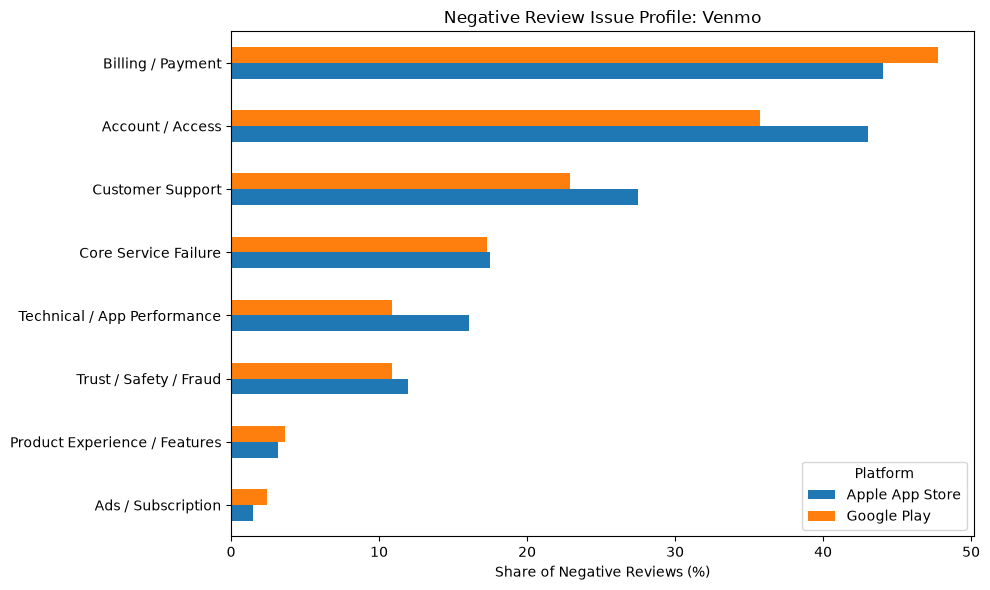

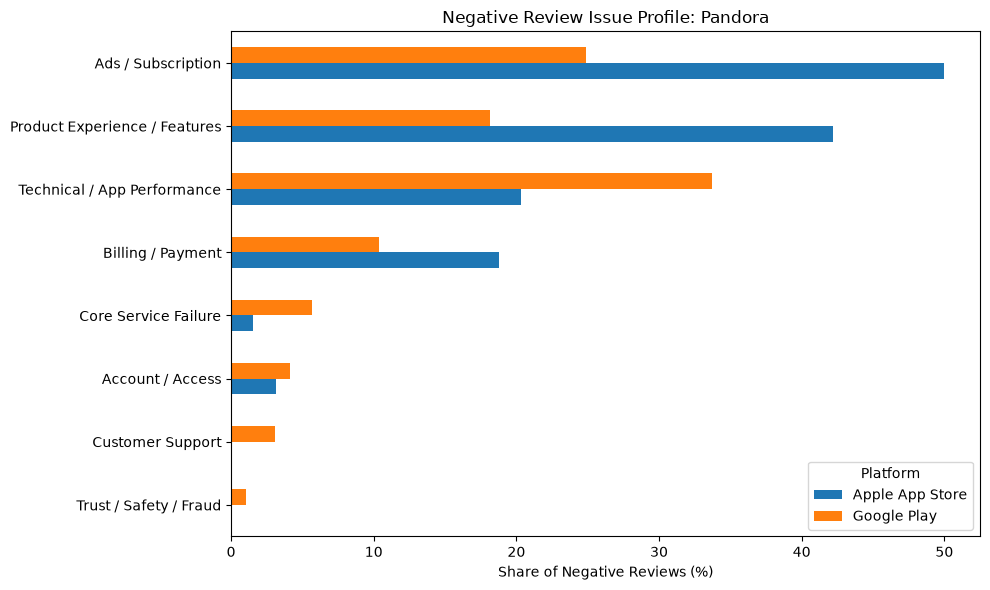

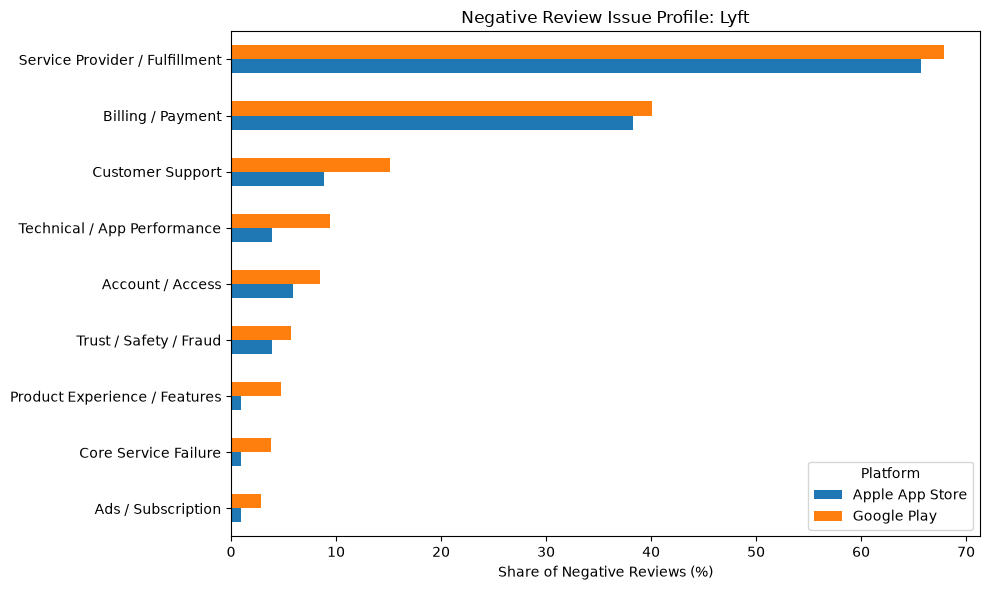

In [49]:
import matplotlib.pyplot as plt

def plot_issue_profile(app_name):
    plot_df = (
        paired_issue_rates[
            paired_issue_rates["app_name"] == app_name
        ]
        .copy()
    )

    plot_df["Max Rate"] = plot_df[
        ["Apple App Store", "Google Play"]
    ].max(axis=1)

    plot_df = plot_df.sort_values(
        "Max Rate",
        ascending=True
    )

    ax = plot_df.plot(
        x="Issue",
        y=["Apple App Store", "Google Play"],
        kind="barh",
        figsize=(10, 6)
    )

    ax.set_title(
        f"Negative Review Issue Profile: {app_name}"
    )
    ax.set_xlabel(
        "Share of Negative Reviews (%)"
    )
    ax.set_ylabel("")
    ax.legend(title="Platform")

    plt.tight_layout()
    plt.show()


for app in ["Venmo", "Pandora", "Lyft"]:
    plot_issue_profile(app)

## 15. Representative Review Validation

Before treating the issue-rate differences as product findings, representative reviews are manually inspected for the issue categories showing the largest cross-platform differences.

This step checks whether the keyword-assisted labels reflect the actual meaning of the review text rather than incidental keyword matches.

The validation focuses on several analytically important cases:

- **Venmo – Account / Access:** more common in Apple negative reviews
- **Pandora – Ads / Subscription:** more common in Apple negative reviews
- **Pandora – Product Experience / Features:** more common in Apple negative reviews
- **Pandora – Technical / App Performance:** more common in Google Play negative reviews
- **Lyft – Customer Support:** somewhat more common in Google Play negative reviews

Representative reviews are sampled from both platforms for comparison.

The purpose is qualitative validation rather than statistical estimation.

In [50]:
def show_issue_examples(
    df,
    app_name,
    issue,
    n=5,
    label_col="issue_labels_v2",
    random_state=42
):
    subset = df[
        (df["app_name"] == app_name)
        & (
            df[label_col].apply(
                lambda labels: issue in labels
            )
        )
    ].copy()

    print(
        f"{app_name} | {issue} | "
        f"Matching reviews: {len(subset)}"
    )

    if len(subset) == 0:
        return subset

    sample = subset.sample(
        n=min(n, len(subset)),
        random_state=random_state
    )

    return sample[
        [
            "rating",
            "review_date",
            "analysis_text",
            label_col
        ]
    ]


validation_cases = [
    ("Venmo", "Account / Access"),
    ("Pandora", "Ads / Subscription"),
    ("Pandora", "Product Experience / Features"),
    ("Pandora", "Technical / App Performance"),
    ("Lyft", "Customer Support")
]


for app_name, issue in validation_cases:

    print("\n" + "=" * 80)
    print(f"{app_name} — {issue}")
    print("=" * 80)

    print("\nAPPLE")
    display(
        show_issue_examples(
            apple_negative,
            app_name,
            issue,
            n=5
        )
    )

    print("\nGOOGLE PLAY")
    display(
        show_issue_examples(
            google_negative,
            app_name,
            issue,
            n=5
        )
    )


Venmo — Account / Access

APPLE
Venmo | Account / Access | Matching reviews: 177


,rating,review_date,analysis_text,issue_labels_v2
12141,1,2026-08-12 19:46:12+00:00,App sucks The app may open once a week for me ...,"[Billing / Payment, Account / Access, Technica..."
12227,1,2026-08-10 18:36:47+00:00,Purchase protection fee If someone you don’t k...,"[Billing / Payment, Account / Access]"
12494,1,2026-08-04 16:00:57+00:00,Will not support fraud. My account was hacked ...,"[Account / Access, Customer Support, Trust / S..."
12184,1,2026-08-11 21:05:46+00:00,Fraud I called in on 2 rather sizable charges ...,"[Account / Access, Trust / Safety / Fraud]"
12301,1,2026-08-08 15:31:05+00:00,Bad timely manner Won’t unfreeze my account af...,"[Billing / Payment, Account / Access]"



GOOGLE PLAY
Venmo | Account / Access | Matching reviews: 89


,rating,review_date,analysis_text,issue_labels_v2
12332,1,2026-08-11 03:07:14+00:00,Absolutely appalling - allows people to send y...,"[Billing / Payment, Account / Access, Trust / ..."
12366,1,2026-08-10 19:18:14+00:00,Tried to log in to my past account I have the ...,"[Billing / Payment, Account / Access, Customer..."
12281,1,2026-08-11 18:58:08+00:00,hard to create a account with. very unhappy 😖,[Account / Access]
12175,1,2026-08-13 00:43:07+00:00,they froze my account because I used it for my...,[Account / Access]
12350,1,2026-08-10 22:53:03+00:00,keep having trouble sending my teen account mo...,"[Billing / Payment, Account / Access, Customer..."



Pandora — Ads / Subscription

APPLE
Pandora | Ads / Subscription | Matching reviews: 32


...

,rating,review_date,analysis_text,issue_labels_v2
6835,1,2026-07-19 21:19:20+00:00,"I barely can listen offline, and I like doing ...","[Billing / Payment, Technical / App Performance]"
6930,2,2026-07-14 12:14:51+00:00,"Battery consumption too high, had to uninstall...",[Technical / App Performance]
6461,1,2026-08-13 01:42:54+00:00,the app continues to crash anytime you try to ...,[Technical / App Performance]
6758,1,2026-07-23 22:49:39+00:00,"cost too much. free version, every time a add ...","[Billing / Payment, Core Service Failure, Tech..."
6550,2,2026-08-06 16:43:13+00:00,"app keeps crashing, all updates have been done...",[Technical / App Performance]



Lyft — Customer Support

APPLE
Lyft | Customer Support | Matching reviews: 9


,rating,review_date,analysis_text,issue_labels_v2
5455,1,2026-08-05 16:25:24+00:00,Beware of Billing Issues Absolutely appalling ...,"[Billing / Payment, Customer Support, Service ..."
5242,1,2026-08-09 05:31:37+00:00,Lacks customer support follow up Over the past...,[Customer Support]
5378,1,2026-08-07 01:10:49+00:00,Scheduled ride credit hard to receive I had a ...,"[Customer Support, Technical / App Performance..."
5152,1,2026-08-10 22:55:25+00:00,Extremely frustrating billing bug + terrible c...,"[Billing / Payment, Customer Support, Technica..."
5458,1,2026-08-05 15:37:56+00:00,Poor customer support They hung up on me as I ...,"[Customer Support, Service Provider / Fulfillm..."



GOOGLE PLAY
Lyft | Customer Support | Matching reviews: 32


,rating,review_date,analysis_text,issue_labels_v2
5477,1,2026-07-28 21:22:03+00:00,I have used your company times in the past but...,"[Customer Support, Service Provider / Fulfillm..."
5201,1,2026-08-06 13:25:12+00:00,Good luck getting any customer service! all su...,[Customer Support]
5429,1,2026-07-30 19:06:56+00:00,"The driver did not show up, and my money was n...","[Billing / Payment, Customer Support, Service ..."
5309,1,2026-08-03 05:39:58+00:00,"Typed in a business name, took me to a residen...","[Billing / Payment, Customer Support, Technica..."
5129,1,2026-08-08 21:33:05+00:00,cannot get a car because no human works for th...,"[Customer Support, Core Service Failure]"


## 16. Qualitative Validation Result

Manual inspection of representative reviews indicates that the Version 2 taxonomy generally captures the intended meaning of the selected issue categories.

The validation samples show clear semantic alignment for:

- Venmo Account / Access complaints, including login, account creation, frozen accounts, and account restrictions
- Pandora Ads / Subscription complaints, including advertising, subscriptions, and paid-plan concerns
- Pandora Product Experience / Features complaints, including repeated songs, search limitations, skipping, and feature availability
- Pandora Technical / App Performance complaints, including crashes, playback failures, performance problems, and device-related issues
- Lyft Customer Support complaints, including difficulty reaching support, poor follow-up, and unresolved service problems

Some reviews receive multiple labels because they describe multiple problems within the same complaint. This is expected under the multi-label taxonomy.

The qualitative spot check provides sufficient support to use Version 2 for exploratory issue-frequency comparisons.

However, the taxonomy should not be interpreted as a formally validated classification model. No manually labeled holdout dataset or statistical classification-accuracy metric is used in the current analysis.